# 문제 4 — 연립방정식과 해의 판정 (가우스 소거·rank·행렬식·역행렬)

풀어야 하는 연립방정식은 다음과 같습니다. 해는 정수로 떨어집니다.

$$\begin{aligned}
3x_1 + x_2 + 2x_3 &= 11\\
x_1 + 4x_2 + x_3 &= 1\\
2x_1 - x_2 + 5x_3 &= 20
\end{aligned}$$

## 이 노트북에서 해야 할 일

| # | 할 일 | 구현할 함수 |
|---|---|---|
| 4-1 | **가우스 소거법을 직접 구현**해 풀고 **각 소거 단계의 첨가행렬을 모두 출력** | `gauss_eliminate` |
| 4-2 | 계수행렬과 첨가행렬의 rank 로 **해의 존재·유일성 판정**, 같을 때와 다를 때의 의미 설명 | `rank` |
| 4-3 | 행렬식과 역행렬을 구하고, **det 이 0 에 가까울 때 왜 위험한지** 설명 | `det`, `inverse_gauss_jordan` |
| 4-4 | **피벗팅 없는** 소거로 첫 피벗이 아주 작을 때의 오차를 재현하고 부분 피벗팅과 비교 | `gauss_eliminate(pivoting=False)` |
| 4-5 | 800x800 에서 `np.linalg.solve` vs `역행렬을 구해서 곱하기` 의 **시간·잔차** 비교 | — |

> `# --- 검증 ---` 셀과 그래프 셀은 제공된 코드입니다. 참조하는 변수 이름을 맞춰 주세요.

In [1]:
import os

# 벤치마크 공정성을 위해 numpy import 전에 BLAS 스레드 수를 1 로 고정한다.
# 수백 x 수백 크기에서는 실제 연산보다 스레드 풀 생성/동기화 오버헤드가 더 커서
# 알고리즘 차이가 통째로 가려질 수 있다.
for _var in ("OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "OMP_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[_var] = "1"

import inspect
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.vectors import det, gauss_eliminate, inverse_gauss_jordan, rank, row_echelon

rng = np.random.default_rng(42)
np.set_printoptions(precision=6, suppress=True)

for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
    if _f in {f.name for f in __import__("matplotlib").font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False


def check(label, condition):
    tag = "PASS" if condition else "FAIL"
    print("[" + tag + "] " + label)
    return bool(condition)


# 풀어야 하는 연립방정식
A = np.array([[3.0, 1.0, 2.0],
              [1.0, 4.0, 1.0],
              [2.0, -1.0, 5.0]])
b = np.array([11.0, 1.0, 20.0])
print("A =\n", A, "\n\nb =", b)

A =
 [[ 3.  1.  2.]
 [ 1.  4.  1.]
 [ 2. -1.  5.]] 

b = [11.  1. 20.]


## 4-1. 가우스 소거법 — 단계별 첨가행렬

가우스 소거는 **첨가행렬 $[A|b]$ 에 행 연산만 적용**해 상삼각으로 만든 뒤
뒤에서부터 대입해 푸는 방법입니다. 행 연산은 해집합을 바꾸지 않습니다.

부분 피벗팅(partial pivoting)은 각 열에서 **절댓값이 가장 큰 성분을 피벗으로**
올리는 행 교환입니다. 왜 그렇게 하는지는 4-4 에서 직접 확인합니다.

**할 일**

- `src/vectors.py` 의 `gauss_eliminate` 를 구현하세요.
  `verbose=True` 면 **초기 첨가행렬과 각 단계(행 교환 / 소거)의 첨가행렬을 모두 출력**해야 합니다.
  반환값 `steps` 에는 단계별 첨가행렬(초기 포함)을 순서대로 담습니다.
- 구현한 소스를 `inspect.getsource` 로 노트북에 출력해 두세요.
- 해를 구하고 `A @ x` 가 `b` 와 같은지, 정수로 떨어지는지 확인하세요.
  **코드를 돌리기 전에 손으로 먼저 풀어 보고** 정수해를 예상해 두세요.

In [2]:
print(inspect.getsource(gauss_eliminate))

def gauss_eliminate(A, b, pivoting: bool = True, verbose: bool = False):
    """가우스 소거법 + 후진대입으로 Ax = b 를 푼다.

    Parameters
    ----------
    pivoting : True 면 부분 피벗팅을 적용한다. False 면 피벗을 그대로 쓴다
               (문제 4-4 에서 두 경우의 오차를 비교하므로 **둘 다 동작해야 한다**).
    verbose  : True 면 각 소거 단계의 첨가행렬 [A|b] 를 출력한다
               (문제 4-1 이 요구하는 '단계별 출력').

    Returns
    -------
    x : 해 벡터
    steps : 단계별 첨가행렬 [A|b] 스냅샷 리스트 (초기 상태 포함)

    피벗이 0 이면 해가 유일하지 않다 -> ZeroDivisionError.
    """
    A = np.asarray(A, dtype=float).copy()
    b = as_vector(b).copy()
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError("A는 정사각 행렬이어야 합니다")
    if b.size != A.shape[0]:
        raise ValueError("b의 길이는 A의 행 개수와 같아야 합니다")

    n = A.shape[0]
    augmented = np.column_stack((A, b))
    scale = max(1.0, float(np.max(np.abs(A))) if A.size else 0.0)
    tol = n * np.finfo(float).eps * scale
    steps = [augmented.copy()]

    for col in range(n - 1):
        if pivoting:
            pivot_row

In [3]:
# TODO: x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)
x, steps = gauss_eliminate(A, b, pivoting=True, verbose=True)

[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.       -1.666667  3.666667 12.666667]]
[[ 3.        1.        2.       11.      ]
 [ 0.        3.666667  0.333333 -2.666667]
 [ 0.        0.        3.818182 11.454545]]


In [4]:
print("최종 해 x:", x)
print("정수해인가:", np.allclose(x, np.round(x)))
print("A @ x:", A @ x)
print("잔차 norm:", np.linalg.norm(A @ x - b))  # 검산용
print("np.linalg.solve(A, b):", np.linalg.solve(A, b))  # 비교 대상

최종 해 x: [ 2. -1.  3.]
정수해인가: True
A @ x: [11.  1. 20.]
잔차 norm: 3.580361673049448e-15
np.linalg.solve(A, b): [ 2. -1.  3.]


In [5]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("해가 (2, -1, 3)", np.allclose(x, [2.0, -1.0, 3.0]))
ok &= check("해가 정수로 떨어진다", np.allclose(x, np.round(x)))
ok &= check("A @ x == b", np.allclose(A @ x, b))
ok &= check("np.linalg.solve 와 일치", np.allclose(x, np.linalg.solve(A, b)))      # 비교 대상
ok &= check("소거 단계가 모두 기록되었다 (단계 수 {} >= 3)".format(len(steps)), len(steps) >= 3)
ok &= check("첫 기록이 초기 첨가행렬 [A|b]", np.allclose(steps[0], np.hstack([A, b.reshape(-1, 1)])))
ok &= check("마지막 첨가행렬이 상삼각", np.allclose(np.tril(steps[-1][:, :3], -1), 0.0))
ok &= check("상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)",
            np.isclose(abs(np.prod(np.diag(steps[-1][:, :3]))), abs(det(A))))
print("\n4-1 전체 통과:", ok)

[PASS] 해가 (2, -1, 3)
[PASS] 해가 정수로 떨어진다
[PASS] A @ x == b
[PASS] np.linalg.solve 와 일치
[PASS] 소거 단계가 모두 기록되었다 (단계 수 3 >= 3)
[PASS] 첫 기록이 초기 첨가행렬 [A|b]
[PASS] 마지막 첨가행렬이 상삼각
[PASS] 상삼각의 대각성분 곱 == ±det(A) (행 연산은 det 의 부호만 바꾼다)

4-1 전체 통과: True


## 4-2. rank 로 해의 존재·유일성 판정

미지수가 $n$개일 때, 루셰-카펠리 정리로 다음처럼 판정합니다.

| 조건 | 판정 |
|---|---|
| $\operatorname{rank}(A)=\operatorname{rank}([A\mid b])=n$ | 유일해 |
| $\operatorname{rank}(A)=\operatorname{rank}([A\mid b])<n$ | 해가 무한히 많음 (자유변수 $n-\operatorname{rank}(A)$개) |
| $\operatorname{rank}(A)<\operatorname{rank}([A\mid b])$ | 해 없음 |

**할 일**

- 이 문제의 두 rank를 `rA`, `rAb`에 구해 판정하세요.
- 두 rank가 같다는 것이 $b$가 $A$의 열공간에 포함된다는 뜻임을 확인하세요.
- 두 rank가 다르면 소거 결과에 모순 행이 나타납니다. 아래 `A_dep`에 모순되는 `b_bad`와 모순 없는 `b_ok`를 각각 넣어 확인하세요.

### 두 rank가 같을 때와 다를 때의 의미

- 같을 때: $b$가 $A$의 열공간에 있으므로 해가 적어도 하나 존재한다.
- 다를 때: $b$가 $A$의 열공간에 없어 모순이 생기므로 해가 없다.
- 같지만 $n$보다 작을 때: 자유변수가 남아 해가 무한히 많다.

In [23]:
Ab = np.hstack([A, b.reshape(-1, 1)])

rA = rank(A)
rAb = rank(Ab)
n_unknowns = A.shape[1]
print("rank(A):", rA)
print("rank([A|b]):", rAb)
print("미지수 개수:", n_unknowns)
print("판정:", "유일해" if rA == rAb == n_unknowns else "무한히 많은 해" if rA == rAb < n_unknowns else "해 없음")
print("np.linalg.matrix_rank(A):", np.linalg.matrix_rank(A))  # 검산용
print("np.linalg.matrix_rank([A|b]):", np.linalg.matrix_rank(Ab))  # 검산용

A_dep = np.array([[1.0, 2.0, 3.0],
                  [3.0, 6.0, 9.0],
                  [1.0, 1.0, 1.0]])
b_bad = np.array([6.0, 20.0, 3.0])
b_ok = np.array([6.0, 18.0, 3.0])
print("A_dep rank:", rank(A_dep))
print("모순 케이스 마지막 행:", row_echelon(np.hstack([A_dep, b_bad.reshape(-1, 1)]))[0][-1])
print("무모순 종속 케이스 마지막 행:", row_echelon(np.hstack([A_dep, b_ok.reshape(-1, 1)]))[0][-1])

rank(A): 3
rank([A|b]): 3
미지수 개수: 3
판정: 유일해
np.linalg.matrix_rank(A): 3
np.linalg.matrix_rank([A|b]): 3
A_dep rank: 2
모순 케이스 마지막 행: [ 0.        0.        0.       -0.666667]
무모순 종속 케이스 마지막 행: [0. 0. 0. 0.]


In [24]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("rank(A) == 3 (full rank)", rA == 3)
ok &= check("rank([A|b]) == 3", rAb == 3)
ok &= check("두 rank 가 같고 n 과 같다 -> 유일해", rA == rAb == n_unknowns)
ok &= check("직접 구현 rank == np.linalg.matrix_rank",                                   # 검산용
            rA == np.linalg.matrix_rank(A) and rAb == np.linalg.matrix_rank(Ab))
ok &= check("A_dep 의 rank 는 2", rank(A_dep) == 2)
ok &= check("모순 케이스는 rank(A) < rank([A|b])",
            rank(A_dep) < rank(np.hstack([A_dep, np.asarray(b_bad, float).reshape(-1, 1)])))
ok &= check("무모순 종속 케이스는 두 rank 가 같고 n 보다 작다",
            rank(A_dep) == rank(np.hstack([A_dep, np.asarray(b_ok, float).reshape(-1, 1)])) < 3)
print("\n4-2 전체 통과:", ok)

[PASS] rank(A) == 3 (full rank)
[PASS] rank([A|b]) == 3
[PASS] 두 rank 가 같고 n 과 같다 -> 유일해
[PASS] 직접 구현 rank == np.linalg.matrix_rank
[PASS] A_dep 의 rank 는 2
[PASS] 모순 케이스는 rank(A) < rank([A|b])
[PASS] 무모순 종속 케이스는 두 rank 가 같고 n 보다 작다

4-2 전체 통과: True


## 4-3. 행렬식과 역행렬 — 그리고 $\det \approx 0$ 의 위험

행렬식은 행 사다리꼴의 **대각성분 곱 x (-1)^(행 교환 횟수)** 로 구합니다.
역행렬은 가우스-조던 소거 $[A|I] \rightarrow [I|A^{-1}]$ 로 구합니다.

**왜 $\det \approx 0$ 일 때 역행렬이 위험한지** 두 관점에서 설명해 보세요.

- 여인수 공식 $A^{-1} = \frac{1}{\det A}\operatorname{adj}(A)$ 에서 무슨 일이 생기는가
- 소거 관점에서 작은 피벗으로 나눈다는 것은 무엇을 뜻하는가

행렬 전체에 $0.01$을 곱하면 $\det$는 작아지지만 조건수는 변하지 않습니다.
따라서 행렬의 단순한 크기보다 특이성에 가까운 정도를 조건수로 판단해야 합니다.

### $\det \approx 0$ 이 위험한 이유와 진짜 판정 기준

- 여인수 공식 관점: $1/\det(A)$가 매우 커져 작은 입력 오차가 해에 크게 증폭된다.
- 소거 관점: 작은 피벗으로 나누는 과정에서 반올림 오차와 유효숫자 손실이 커진다.
- 스케일 실험에서 관찰한 것: 행렬 전체를 작게 만들어도 해와 조건수는 본질적으로 변하지 않지만 행렬식만 작아진다.
- 실무 판정 기준과 그 의미: $\operatorname{cond}(A)$를 사용하며, 조건수가 클수록 작은 입력 오차가 해에 크게 증폭된다.

In [25]:
detA = det(A)
invA = inverse_gauss_jordan(A)
print("det(A):", detA)
print("np.linalg.det(A):", np.linalg.det(A))  # 검산용
print("A^-1:\n", invA)
print("np.linalg.inv(A):\n", np.linalg.inv(A))  # 검산용
print("A @ A^-1:\n", A @ invA)
print("A^-1 @ b:", invA @ b)
print("4-1 해와 일치:", np.allclose(invA @ b, x))

det(A): 42.0
np.linalg.det(A): 42.00000000000001
A^-1:
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
np.linalg.inv(A):
 [[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
A @ A^-1:
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]
A^-1 @ b: [ 2. -1.  3.]
4-1 해와 일치: True


In [26]:
scales = [1.0, 1e-1, 1e-2, 1e-3]
print("스케일 실험: scale | det | cond | 해 상대오차")
for scale in scales:
    A_scaled = scale * A
    b_scaled = scale * b
    x_scaled, _ = gauss_eliminate(A_scaled, b_scaled, pivoting=True)
    relative_error = np.linalg.norm(x_scaled - x) / np.linalg.norm(x)
    print(scale, det(A_scaled), np.linalg.cond(A_scaled), relative_error)

print("\n거의 특이행렬 실험: eps | det | cond | 해 상대오차")
for eps in [1e-1, 1e-3, 1e-5, 1e-8, 1e-12]:
    A_near = np.array([[1.0, 2.0], [2.0, 4.0 + eps]])
    b_near = np.array([3.0, 6.0 + eps])
    x_near = np.linalg.solve(A_near, b_near)  # 비교 대상
    relative_error = np.linalg.norm(x_near - [1.0, 1.0]) / np.linalg.norm([1.0, 1.0])
    print(eps, det(A_near), np.linalg.cond(A_near), relative_error)

스케일 실험: scale | det | cond | 해 상대오차
1.0 42.0 4.214603188956883 0.0
0.1 0.04200000000000001 4.214603188956881 2.517749162550945e-16
0.01 4.2000000000000004e-05 4.214603188956882 4.672744687265428e-16
0.001 4.2000000000000006e-08 4.214603188956883 1.4835979218054372e-16

거의 특이행렬 실험: eps | det | cond | 해 상대오차
0.1 0.09999999999999964 258.09612547457454 0.0
0.001 0.001000000000000334 25008.000959970956 0.0
1e-05 9.999999999621423e-06 2500007.999573454 0.0
1e-08 9.99999993922529e-09 2499999737.4641685 0.0
1e-12 1.000088900582341e-12 24976078646444.38 0.0


In [28]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("det(A) == 42", np.isclose(detA, 42.0))
ok &= check("직접 구현 det == np.linalg.det", np.isclose(detA, np.linalg.det(A)))            # 검산용
ok &= check("A @ A^-1 == I", np.allclose(A @ invA, np.eye(3)))
ok &= check("A^-1 @ A == I", np.allclose(invA @ A, np.eye(3)))
ok &= check("직접 구현 역행렬 == np.linalg.inv", np.allclose(invA, np.linalg.inv(A)))       # 검산용
ok &= check("A^-1 @ b == 가우스 소거 해", np.allclose(invA @ b, x))
ok &= check("det(A^-1) == 1/det(A)", np.isclose(det(invA), 1.0 / detA))
ok &= check("det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)",
            np.isclose(det(0.01 * A), 1e-6 * detA))
ok &= check("조건수는 스케일에 무관", np.isclose(np.linalg.cond(0.01 * A), np.linalg.cond(A)))
print("\n4-3 전체 통과:", ok)

[PASS] det(A) == 42
[PASS] 직접 구현 det == np.linalg.det
[PASS] A @ A^-1 == I
[PASS] A^-1 @ A == I
[PASS] 직접 구현 역행렬 == np.linalg.inv
[PASS] A^-1 @ b == 가우스 소거 해
[PASS] det(A^-1) == 1/det(A)
[PASS] det(0.01 A) == 0.01^3 det(A) (det 은 스케일에 민감)
[PASS] 조건수는 스케일에 무관

4-3 전체 통과: True


## 4-4. 피벗팅 없는 소거의 오차

첫 피벗이 아주 작은 고전적인 예제입니다.

$$\begin{bmatrix}\varepsilon & 1\\ 1 & 1\end{bmatrix}
\begin{bmatrix}x_1\\x_2\end{bmatrix}=\begin{bmatrix}1\\2\end{bmatrix},
\qquad \text{참해}\; x_1=\frac{1}{1-\varepsilon},\; x_2=\frac{1-2\varepsilon}{1-\varepsilon}$$

**할 일**

- `pivoting=False`와 `True`로 각각 풀어 참해와의 상대오차를 비교하세요.
- $\varepsilon$을 $10^{-2}$에서 $10^{-16}$까지 줄여 가며 두 오차를 표로 출력하고 그래프로 확인하세요.
- 피벗팅이 없을 때 **정확히 어느 연산에서 유효숫자가 날아가는지** 설명하세요.

### 피벗팅 없이 소거하면 무슨 일이 일어나는가

- 첫 피벗 $\varepsilon$로 두 번째 행을 소거할 때 $1/\varepsilon$이라는 큰 배율이 생긴다. 이 과정에서 작은 수치 오차가 증폭되고, $\varepsilon$이 기계 정밀도에 가까워질수록 유효숫자를 잃는다.

In [29]:
def solve_eps(eps):
    """eps 하나에 대해 참해와 두 피벗 전략의 상대오차를 반환한다."""
    Ae = np.array([[eps, 1.0], [1.0, 1.0]])
    be = np.array([1.0, 2.0])
    exact = np.array([1.0 / (1.0 - eps), (1.0 - 2.0 * eps) / (1.0 - eps)])
    try:
        x_no, _ = gauss_eliminate(Ae, be, pivoting=False)
        rel_err_no = np.linalg.norm(x_no - exact) / np.linalg.norm(exact)
    except ZeroDivisionError:
        x_no = np.full(2, np.nan)
        rel_err_no = 1.0
    x_pp, _ = gauss_eliminate(Ae, be, pivoting=True)
    rel_err_pp = np.linalg.norm(x_pp - exact) / np.linalg.norm(exact)
    return exact, x_no, x_pp, rel_err_no, rel_err_pp

EPS = 1e-5
eps_list = np.logspace(-2, -16, 15)
exact, x_no, x_pp, err_no, err_pp = solve_eps(EPS)
print("참해:", exact)
print("피벗팅 없음:", x_no, "상대오차:", err_no)
print("부분 피벗팅:", x_pp, "상대오차:", err_pp)

errs_no, errs_pp = [], []
for eps in eps_list:
    _, _, _, error_no, error_pp = solve_eps(eps)
    errs_no.append(max(error_no, 1e-18))
    errs_pp.append(max(error_pp, 1e-18))
for eps, error_no, error_pp in zip(eps_list, errs_no, errs_pp):
    print("eps={:.1e}: no-pivot={:.3e}, partial-pivot={:.3e}".format(eps, error_no, error_pp))

참해: [1.00001 0.99999]
피벗팅 없음: [1.00001 0.99999] 상대오차: 2.6901964197197188e-12
부분 피벗팅: [1.00001 0.99999] 상대오차: 0.0
eps=1.0e-02: no-pivot=3.297e-15, partial-pivot=1.570e-16
eps=1.0e-03: no-pivot=1.601e-14, partial-pivot=1.000e-18
eps=1.0e-04: no-pivot=1.989e-13, partial-pivot=1.570e-16
eps=1.0e-05: no-pivot=2.690e-12, partial-pivot=1.000e-18
eps=1.0e-06: no-pivot=3.984e-12, partial-pivot=1.570e-16
eps=1.0e-07: no-pivot=3.563e-10, partial-pivot=1.000e-18
eps=1.0e-08: no-pivot=3.518e-09, partial-pivot=1.570e-16
eps=1.0e-09: no-pivot=2.071e-08, partial-pivot=1.000e-18
eps=1.0e-10: no-pivot=5.844e-08, partial-pivot=1.000e-18
eps=1.0e-11: no-pivot=5.850e-08, partial-pivot=1.000e-18
eps=1.0e-12: no-pivot=1.564e-05, partial-pivot=1.000e-18
eps=1.0e-13: no-pivot=2.199e-04, partial-pivot=1.570e-16
eps=1.0e-14: no-pivot=5.652e-04, partial-pivot=1.000e-18
eps=1.0e-15: no-pivot=5.652e-04, partial-pivot=1.570e-16
eps=1.0e-16: no-pivot=1.000e+00, partial-pivot=1.570e-16


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

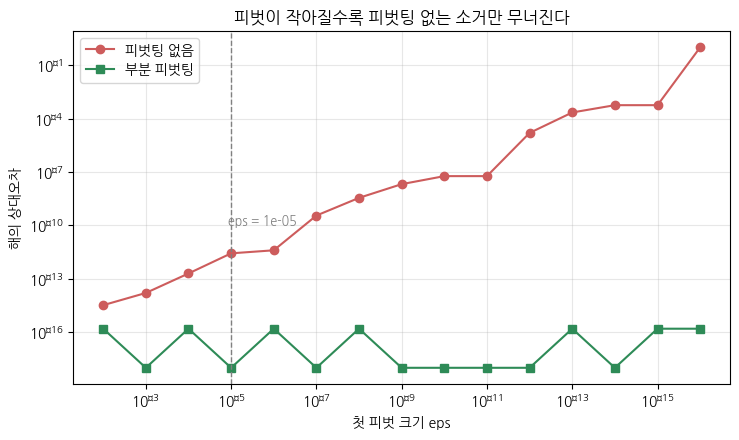

In [30]:
# --- 그래프 (제공 코드) ---
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.loglog(eps_list, errs_no, "o-", color="indianred", label="피벗팅 없음")
ax.loglog(eps_list, errs_pp, "s-", color="seagreen", label="부분 피벗팅")
ax.axvline(EPS, ls="--", color="gray", lw=1)
ax.text(EPS * 1.2, 1e-10, "eps = {:g}".format(EPS), color="gray", fontsize=9)
ax.invert_xaxis()
ax.set_xlabel("첫 피벗 크기 eps")
ax.set_ylabel("해의 상대오차")
ax.set_title("피벗이 작아질수록 피벗팅 없는 소거만 무너진다")
ax.grid(alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

In [15]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다", err_no > err_pp)
ok &= check("부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)", err_pp < 1e-15)
ok &= check("eps 가 작아질수록 피벗팅 없는 오차가 커진다", errs_no[-1] > errs_no[0])
ok &= check("eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)", errs_no[-1] > 0.1)
ok &= check("부분 피벗팅은 eps 와 무관하게 안정적", max(errs_pp) < 1e-14)
ok &= check("피벗팅 결과는 np.linalg.solve 와 일치",                                          # 비교 대상
            np.allclose(x_pp, np.linalg.solve(np.array([[EPS, 1.0], [1.0, 1.0]]), [1.0, 2.0])))
print("\n4-4 전체 통과:", ok)

[PASS] eps=1e-5 에서 피벗팅 없는 쪽의 오차가 더 크다
[PASS] 부분 피벗팅 오차는 기계정밀도 수준 (< 1e-15)
[PASS] eps 가 작아질수록 피벗팅 없는 오차가 커진다
[PASS] eps=1e-16 근처에서는 피벗팅 없는 해가 완전히 무너진다 (오차 > 0.1)
[PASS] 부분 피벗팅은 eps 와 무관하게 안정적
[PASS] 피벗팅 결과는 np.linalg.solve 와 일치

4-4 전체 통과: True


## 4-5. 800x800 — `solve` vs `역행렬을 구해서 곱하기`

**할 일**

- 800x800 무작위 행렬에서 `np.linalg.solve(A, b)`와 `np.linalg.inv(A) @ b`의 실행 시간과 잔차를 비교하세요.
- 벤치마크는 워밍업 1회 후 여러 번 재서 최솟값을 씁니다. 최솟값은 일시적인 시스템 부하의 영향을 덜 받는 대표적인 최선 성능입니다.
- 조건수를 지정한 행렬에서 조건수별 해의 상대오차도 비교하세요.

### 결론 — 실무에서는 무엇을 쓰는가

- 연산량: 한 우변에서는 `solve`가 약 $O(n^3)$이고, 역행렬 계산 후 곱하기는 역행렬 계산 $O(n^3)$에 곱셈 $O(n^2)$가 추가된다.
- 정확도: 일반적으로 `solve`가 더 안정적이고 잔차가 작다.
- 메모리: `inv`는 $n\times n$ 역행렬을 별도로 저장한다.
- 우변이 여러 개일 때는: 같은 계수행렬이면 한 번 분해한 뒤 여러 우변을 함께 `solve`한다.
- 예외적으로 역행렬을 명시적으로 구해야 하는 경우: 실제 역행렬 자체가 결과로 필요할 때만 구한다.

In [31]:
N = 800
A_big = rng.standard_normal((N, N))
b_big = rng.standard_normal(N)
REPEAT = 10


def bench(fn, repeat=REPEAT):
    """워밍업 1회 후 repeat 번 재서 최솟값을 쓴다. (그대로 쓰면 됩니다)"""
    fn()
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        out = fn()
        best = min(best, time.perf_counter() - t0)
    return best, out


t_solve, x_solve = bench(lambda: np.linalg.solve(A_big, b_big))
t_inv, x_inv = bench(lambda: np.linalg.inv(A_big) @ b_big)
res_solve = np.linalg.norm(A_big @ x_solve - b_big)
res_inv = np.linalg.norm(A_big @ x_inv - b_big)
print("solve: {:.3f} ms, residual: {:.3e}".format(t_solve * 1e3, res_solve))
print("inv @ b: {:.3f} ms, residual: {:.3e}".format(t_inv * 1e3, res_inv))
print("역행렬 메모리: {:.2f} MB".format(N * N * 8 / 1024**2))

solve: 8.499 ms, residual: 5.395e-11
inv @ b: 28.572 ms, residual: 7.301e-11
역행렬 메모리: 4.88 MB


In [32]:
print("조건수별 solve / inv@b 상대오차")
Q1, _ = np.linalg.qr(rng.standard_normal((80, 80)))
Q2, _ = np.linalg.qr(rng.standard_normal((80, 80)))
for condition_target in [1e1, 1e3, 1e6, 1e10]:
    singular_values = np.logspace(0, -np.log10(condition_target), 80)
    A_conditioned = (Q1 * singular_values) @ Q2.T
    x_true = rng.standard_normal(80)
    b_conditioned = A_conditioned @ x_true
    x_solve_conditioned = np.linalg.solve(A_conditioned, b_conditioned)
    x_inv_conditioned = np.linalg.inv(A_conditioned) @ b_conditioned
    solve_error = np.linalg.norm(x_solve_conditioned - x_true) / np.linalg.norm(x_true)
    inv_error = np.linalg.norm(x_inv_conditioned - x_true) / np.linalg.norm(x_true)
    print("cond={:.1e}: solve={:.3e}, inv@b={:.3e}".format(condition_target, solve_error, inv_error))

조건수별 solve / inv@b 상대오차
cond=1.0e+01: solve=1.850e-15, inv@b=2.764e-15
cond=1.0e+03: solve=1.523e-14, inv@b=1.002e-13
cond=1.0e+06: solve=9.183e-12, inv@b=9.239e-11
cond=1.0e+10: solve=9.070e-08, inv@b=8.524e-07


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


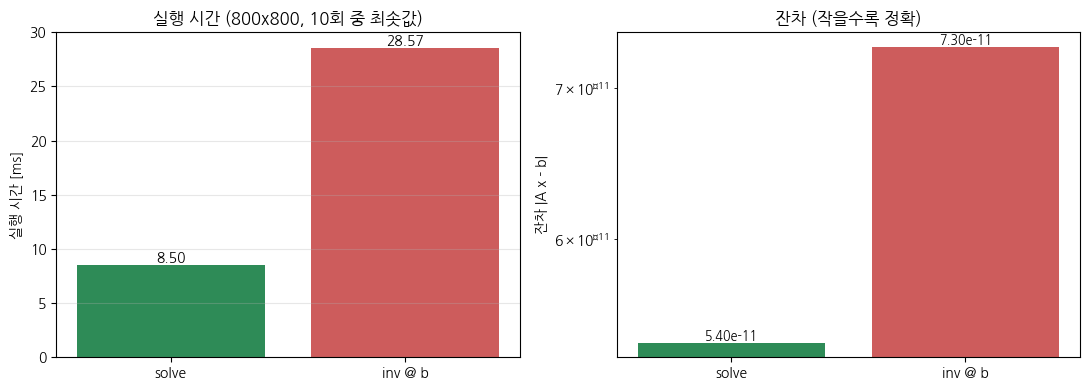

In [33]:
# --- 그래프 (제공 코드) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
names = ["solve", "inv @ b"]

axes[0].bar(names, [t_solve * 1e3, t_inv * 1e3], color=["seagreen", "indianred"])
axes[0].set_ylabel("실행 시간 [ms]")
axes[0].set_title("실행 시간 ({0}x{0}, {1}회 중 최솟값)".format(N, REPEAT))
for i, v in enumerate([t_solve * 1e3, t_inv * 1e3]):
    axes[0].text(i, v, "{:.2f}".format(v), ha="center", va="bottom")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(names, [res_solve, res_inv], color=["seagreen", "indianred"])
axes[1].set_ylabel("잔차 |A x - b|")
axes[1].set_yscale("log")
axes[1].set_title("잔차 (작을수록 정확)")
for i, v in enumerate([res_solve, res_inv]):
    axes[1].text(i, v, "{:.2e}".format(v), ha="center", va="bottom", fontsize=9)
axes[1].grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

In [34]:
# --- 검증 --- (제공 코드: 수정하지 마세요)
ok = check("두 방법의 해가 사실상 같다", np.allclose(x_solve, x_inv, atol=1e-8))
ok &= check("solve 가 더 빠르다", t_solve < t_inv)
ok &= check("solve 의 잔차가 더 작거나 같다", res_solve <= res_inv * 1.5)
ok &= check("두 해 모두 유효 (잔차가 작다)", res_solve < 1e-8 and res_inv < 1e-8)
print("\n4-5 전체 통과:", ok)

[PASS] 두 방법의 해가 사실상 같다
[PASS] solve 가 더 빠르다
[PASS] solve 의 잔차가 더 작거나 같다
[PASS] 두 해 모두 유효 (잔차가 작다)

4-5 전체 통과: True


## 답안 템플릿 정리

In [35]:
summary = """
1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = {x}

2. rank A: {rA} / rank 첨가행렬: {rAb}   (미지수 {n}개)
   - 해의 존재·유일성 판정: rank(A) = rank([A|b]) = n 이므로 유일해
   - 두 rank가 같을 때: 해가 존재한다. 다를 때: 해가 없다. 같지만 n보다 작을 때: 해가 무한히 많다.

3. 행렬식: {detA}
   역행렬:
{invA}
   - det이 0에 가까우면 역행렬 공식의 1/det 항과 작은 피벗 나눗셈 때문에 오차가 증폭된다.
   - 실제 판정 기준: 조건수 cond(A)를 사용한다. 조건수가 클수록 입력 오차에 민감하다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): {err_no:.3e} / {err_pp:.3e}
   - eps를 더 줄이면: 피벗팅 없는 방법의 오차가 급격히 커진다.
   - 유효숫자가 날아가는 지점: 작은 첫 피벗으로 나누어 큰 소거 배율이 생기는 단계

5. solve vs 역행렬 곱셈 (800x800)
   - 시간: {t_solve:.3f} ms / {t_inv:.3f} ms
   - 잔차: {res_solve:.3e} / {res_inv:.3e}
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 커질수록 두 방법 모두 오차가 증가하며, 일반적으로 inv@b가 더 불리하다.
   - 결론: 역행렬이 직접 필요하지 않으면 np.linalg.solve를 사용한다.
""".format(
    x=np.array2string(x, precision=6),
    rA=rA,
    rAb=rAb,
    n=n_unknowns,
    detA=detA,
    invA=np.array2string(invA, precision=6),
    err_no=err_no,
    err_pp=err_pp,
    t_solve=t_solve * 1e3,
    t_inv=t_inv * 1e3,
    res_solve=res_solve,
    res_inv=res_inv,
)
print(summary)


1. 가우스 소거 단계별 첨가행렬: 4-1 셀 출력 참조
   최종 해: x = [ 2. -1.  3.]

2. rank A: 3 / rank 첨가행렬: 3   (미지수 3개)
   - 해의 존재·유일성 판정: rank(A) = rank([A|b]) = n 이므로 유일해
   - 두 rank가 같을 때: 해가 존재한다. 다를 때: 해가 없다. 같지만 n보다 작을 때: 해가 무한히 많다.

3. 행렬식: 42.0
   역행렬:
[[ 0.5      -0.166667 -0.166667]
 [-0.071429  0.261905 -0.02381 ]
 [-0.214286  0.119048  0.261905]]
   - det이 0에 가까우면 역행렬 공식의 1/det 항과 작은 피벗 나눗셈 때문에 오차가 증폭된다.
   - 실제 판정 기준: 조건수 cond(A)를 사용한다. 조건수가 클수록 입력 오차에 민감하다.

4. 피벗팅 없을 때 오차 / 부분 피벗팅 오차 (eps = 1e-5): 2.690e-12 / 0.000e+00
   - eps를 더 줄이면: 피벗팅 없는 방법의 오차가 급격히 커진다.
   - 유효숫자가 날아가는 지점: 작은 첫 피벗으로 나누어 큰 소거 배율이 생기는 단계

5. solve vs 역행렬 곱셈 (800x800)
   - 시간: 8.499 ms / 28.572 ms
   - 잔차: 5.395e-11 / 7.301e-11
   - 조건수를 키웠을 때의 정확도 차이: 조건수가 커질수록 두 방법 모두 오차가 증가하며, 일반적으로 inv@b가 더 불리하다.
   - 결론: 역행렬이 직접 필요하지 않으면 np.linalg.solve를 사용한다.

